# 01 – Black-Scholes: pricing analítico de opciones europeas

En este notebook usamos las fórmulas cerradas de **Black-Scholes-Merton** para valorar opciones call y put europeas, calculamos las principales griegas y comparamos el resultado con una aproximación de Monte Carlo.

Fórmulas:

$$
d_1 = \frac{\ln(S/K) + (r - q + \sigma^2/2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}
$$

Call: $C = S e^{-qT} N(d_1) - K e^{-rT} N(d_2)$

Put:  $P = K e^{-rT} N(-d_2) - S e^{-qT} N(-d_1)$

In [1]:
import sys
from pathlib import Path

# Agregar src al path de importación
sys.path.append(str(Path(".").resolve().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from black_scholes import (
    call_price, put_price, call_delta, put_delta, gamma, vega,
    call_theta, put_theta, call_rho, put_rho, implied_volatility
)
from simulation import mc_call_price, mc_put_price

plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

## 1. Ejemplo numérico básico

In [2]:
S = 100      # spot
K = 100      # strike
T = 1.0      # años al vencimiento
r = 0.05     # tasa libre de riesgo
sigma = 0.2  # volatilidad
q = 0.0      # dividendos

call = call_price(S, K, T, r, sigma, q)
put = put_price(S, K, T, r, sigma, q)

print(f"Call: {call:.4f}")
print(f"Put:  {put:.4f}")
print(f"Paridad put-call C - P = {call - put:.4f}")
print(f"S*exp(-qT) - K*exp(-rT) = {S*np.exp(-q*T) - K*np.exp(-r*T):.4f}")

Call: 10.4506
Put:  5.5735
Paridad put-call C - P = 4.8771
S*exp(-qT) - K*exp(-rT) = 4.8771


## 2. Griegas principales

In [3]:
greeks = pd.DataFrame({
    "Call": [
        call_delta(S, K, T, r, sigma, q),
        gamma(S, K, T, r, sigma, q),
        vega(S, K, T, r, sigma, q),
        call_theta(S, K, T, r, sigma, q),
        call_rho(S, K, T, r, sigma, q),
    ],
    "Put": [
        put_delta(S, K, T, r, sigma, q),
        gamma(S, K, T, r, sigma, q),
        vega(S, K, T, r, sigma, q),
        put_theta(S, K, T, r, sigma, q),
        put_rho(S, K, T, r, sigma, q),
    ]
}, index=["Delta", "Gamma", "Vega", "Theta", "Rho"])

greeks

,Call,Put
Delta,0.636831,-0.363169
Gamma,0.018762,0.018762
Vega,37.524035,37.524035
Theta,-6.414028,-1.657880
Rho,53.232482,-41.890461


## 3. Precio de la call en función del spot

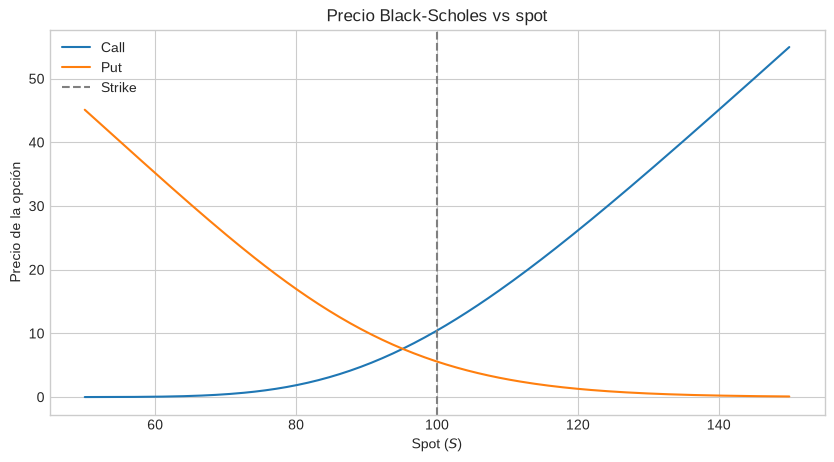

In [4]:
spots = np.linspace(50, 150, 200)
calls = [call_price(s, K, T, r, sigma, q) for s in spots]
puts = [put_price(s, K, T, r, sigma, q) for s in spots]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(spots, calls, label="Call")
ax.plot(spots, puts, label="Put")
ax.axvline(K, color="gray", linestyle="--", label="Strike")
ax.set_xlabel("Spot ($S$)")
ax.set_ylabel("Precio de la opción")
ax.set_title("Precio Black-Scholes vs spot")
ax.legend()
plt.show()

## 4. Volatilidad implícita

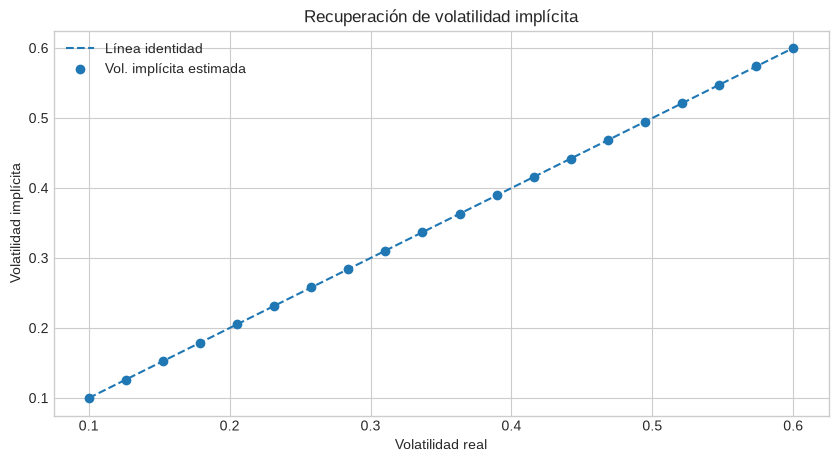

In [5]:
# Simulamos precios de mercado con diferentes volatilidades implícitas
true_vols = np.linspace(0.1, 0.6, 20)
market_prices = [call_price(S, K, T, r, vol) for vol in true_vols]
iv_estimates = [implied_volatility(p, S, K, T, r, option_type="call") for p in market_prices]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(true_vols, true_vols, "--", label="Línea identidad")
ax.scatter(true_vols, iv_estimates, label="Vol. implícita estimada", zorder=3)
ax.set_xlabel("Volatilidad real")
ax.set_ylabel("Volatilidad implícita")
ax.set_title("Recuperación de volatilidad implícita")
ax.legend()
plt.show()

## 5. Superficie de precios: spot vs volatilidad

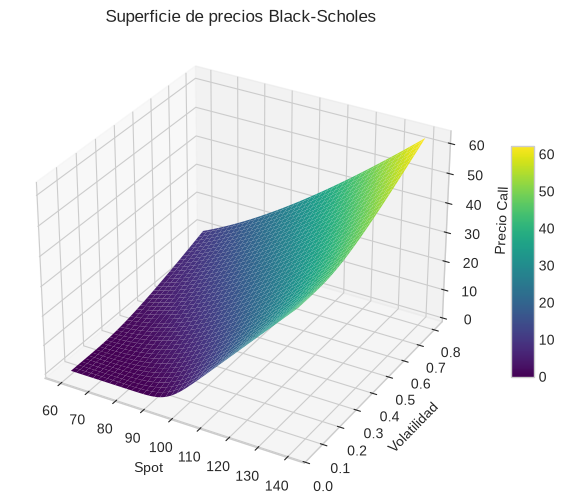

In [6]:
spots_grid = np.linspace(60, 140, 80)
vols_grid = np.linspace(0.05, 0.8, 80)
S_mesh, V_mesh = np.meshgrid(spots_grid, vols_grid)

price_mesh = call_price(S_mesh, K, T, r, V_mesh, q)

fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": "3d"})
surf = ax.plot_surface(S_mesh, V_mesh, price_mesh, cmap="viridis", edgecolor="none")
ax.set_xlabel("Spot")
ax.set_ylabel("Volatilidad")
ax.set_zlabel("Precio Call")
ax.set_title("Superficie de precios Black-Scholes")
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()

## 6. Validación: Black-Scholes vs Monte Carlo

In [7]:
mc_call, se_call = mc_call_price(S, K, T, r, sigma, n_paths=200_000, random_state=42)
mc_put, se_put = mc_put_price(S, K, T, r, sigma, n_paths=200_000, random_state=42)

comparison = pd.DataFrame({
    "Black-Scholes": [call, put],
    "Monte Carlo": [mc_call, mc_put],
    "Error MC": [se_call, se_put],
    "Diferencia": [call - mc_call, put - mc_put]
}, index=["Call", "Put"])

comparison

,Black-Scholes,Monte Carlo,Error MC,Diferencia
Call,10.450584,10.463414,0.033118,-0.012830
Put,5.573526,5.588904,0.019390,-0.015378


## Ejercicios propuestos

1. Graficar la gamma y la vega en función del spot. ¿Dónde alcanzan su máximo?
2. Calcular el precio de una opción con dividendos ($q > 0$) y comparar con $q=0$.
3. Implementar una función que grafique el smile de volatilidad a partir de strikes y precios de mercado.